# 07 — Anotaciones, texto y elementos de referencia

Las anotaciones transforman un gráfico informativo en uno comunicativo. Una flecha apuntando a un pico, una línea de referencia, o un texto en el momento correcto explica el dato sin necesitar una leyenda.

## Setup

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
from pathlib import Path

def find_project_root():
    for parent in [Path.cwd()] + list(Path.cwd().parents):
        if (parent / 'data').exists():
            return parent

ROOT  = find_project_root()
TRAIN = ROOT / 'data' / 'external' / 'train.csv'
AIR   = ROOT / 'data' / 'external' / 'Listings.csv'

df = pd.read_csv(TRAIN, low_memory=False)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
ventas_mes = (
    df.groupby(df['Order Date'].dt.to_period('M').astype(str))['Sales']
    .sum()
    .reset_index()
)
ventas_mes.columns = ['mes', 'revenue']
print(ventas_mes.tail())


        mes      revenue
43  2018-08   62837.8480
44  2018-09   86152.8880
45  2018-10   77448.1312
46  2018-11  117938.1550
47  2018-12   83030.3888


## Líneas de referencia — `axvline` y `axhline`

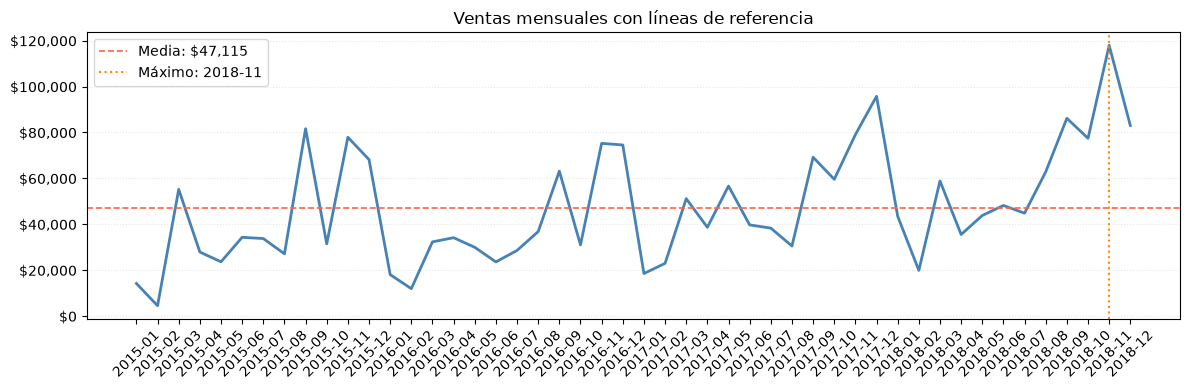

In [2]:
media = ventas_mes['revenue'].mean()
idx_max = ventas_mes['revenue'].idxmax()
mes_max = ventas_mes.loc[idx_max, 'mes']

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(ventas_mes['mes'], ventas_mes['revenue'],
        color='steelblue', linewidth=2)

# Línea horizontal de referencia — media
ax.axhline(media, color='tomato', linestyle='--', linewidth=1.2,
           label=f'Media: ${media:,.0f}')

# Línea vertical — mes con máximo revenue
ax.axvline(mes_max, color='darkorange', linestyle=':', linewidth=1.5,
           label=f'Máximo: {mes_max}')

ax.set_title('Ventas mensuales con líneas de referencia')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()


## `ax.text()` — texto en coordenadas del gráfico

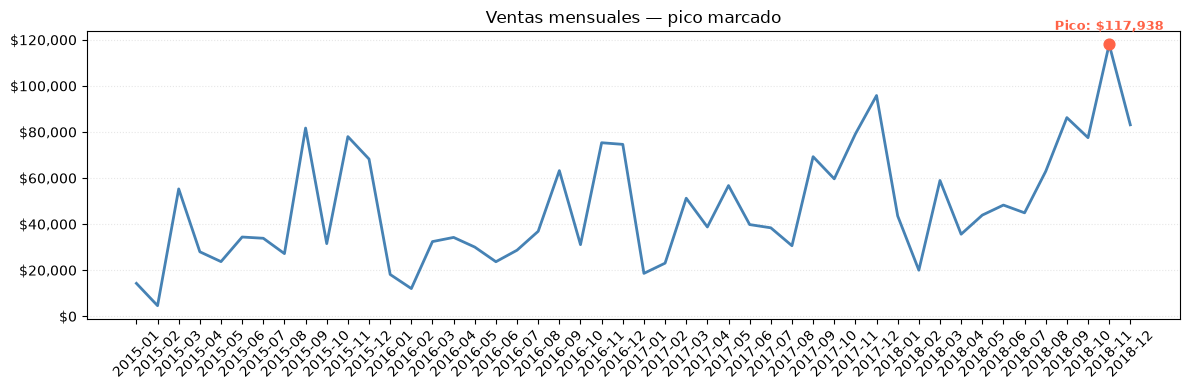

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ventas_mes['mes'], ventas_mes['revenue'],
        color='steelblue', linewidth=2)

# Anotar el punto máximo
rev_max = ventas_mes.loc[idx_max, 'revenue']
ax.text(
    idx_max,          # posición X (índice numérico)
    rev_max + 5000,   # posición Y (un poco arriba del punto)
    f'Pico: ${rev_max:,.0f}',
    ha='center',      # alineación horizontal
    va='bottom',      # alineación vertical
    fontsize=9,
    color='tomato',
    fontweight='bold',
)

# Marcar el punto
ax.scatter([idx_max], [rev_max], color='tomato', s=60, zorder=5)

ax.set_title('Ventas mensuales — pico marcado')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()


## `ax.annotate()` — texto con flecha

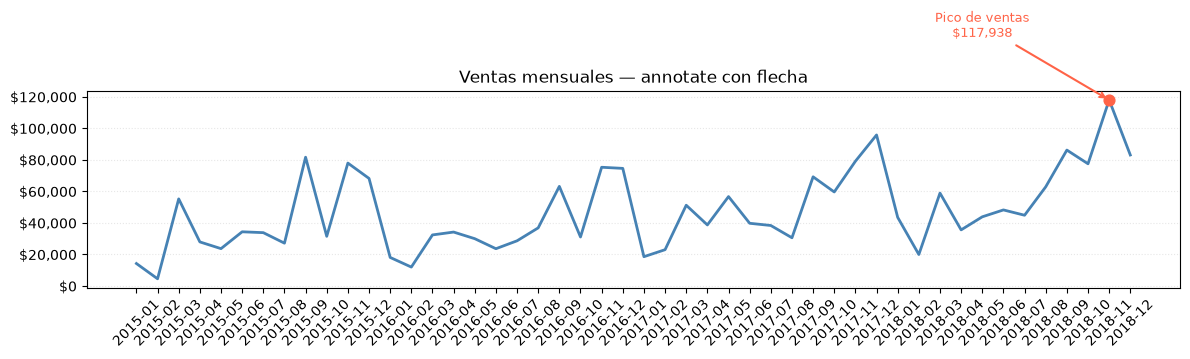

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ventas_mes['mes'], ventas_mes['revenue'],
        color='steelblue', linewidth=2)

rev_max = ventas_mes.loc[idx_max, 'revenue']

ax.annotate(
    text=f'Pico de ventas\n${rev_max:,.0f}',
    xy=(idx_max, rev_max),            # donde apunta la flecha
    xytext=(idx_max - 6, rev_max + 40000),  # donde está el texto
    fontsize=9,
    color='tomato',
    arrowprops=dict(
        arrowstyle='->',
        color='tomato',
        lw=1.5,
    ),
    ha='center',
)

ax.scatter([idx_max], [rev_max], color='tomato', s=60, zorder=5)
ax.set_title('Ventas mensuales — annotate con flecha')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()


## `ax.fill_between()` — área sombreada

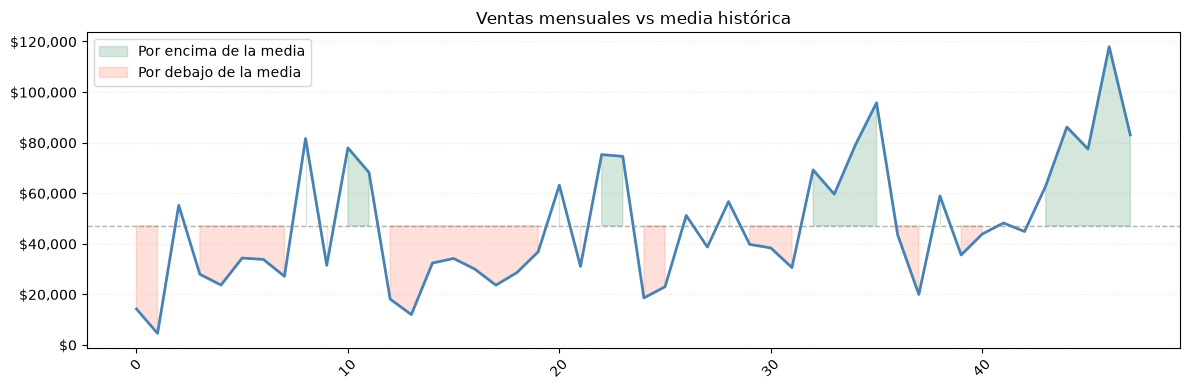

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))

x = ventas_mes.index
y = ventas_mes['revenue']
media = y.mean()

ax.plot(x, y, color='steelblue', linewidth=2)
ax.axhline(media, color='gray', linestyle='--', linewidth=1, alpha=0.6)

# Verde donde está por encima de la media, rojo donde está por debajo
ax.fill_between(x, y, media,
                where=(y >= media), alpha=0.2, color='seagreen',
                label='Por encima de la media')
ax.fill_between(x, y, media,
                where=(y < media),  alpha=0.2, color='tomato',
                label='Por debajo de la media')

ax.set_title('Ventas mensuales vs media histórica')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()


---
## Resumen

| Elemento | Función | Cuándo usarlo |
|----------|---------|---------------|
| Línea horizontal | `ax.axhline(y)` | Objetivo, media, umbral |
| Línea vertical | `ax.axvline(x)` | Fecha clave, corte |
| Texto libre | `ax.text(x, y, 'texto')` | Etiquetar puntos específicos |
| Texto con flecha | `ax.annotate(text, xy=..., xytext=...)` | Señalar algo que requiere explicación |
| Área sombreada | `ax.fill_between(x, y1, y2)` | Rango, diferencia respecto a referencia |
